In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!wget $data

--2026-09-19 21:18:46--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  1.01MB/s    in 1.4s    

2026-09-19 21:18:48 (1.01 MB/s) - ‘data.csv’ saved [1475504/1475504]



In [5]:
df = pd.read_csv('data.csv')

In [30]:
# data preparation

df.columns = df.columns.str.replace(' ', '_').str.lower()
strings = list(df.dtypes[df.dtypes == 'str'].index)
for col in strings:
    df[col] = df[col].str.replace(' ', '_').str.lower()
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [35]:
# Explaratory data analysis
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print(f"{df[col].isnull().sum()} null values")
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
0 null values

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
0 null values

year
[2011 2012 2013 1992 1993]
28
0 null values

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
3 null values

engine_hp
[335. 300. 230. 320. 172.]
356
69 null values

engine_cylinders
[ 6.  4.  5.  8. 12.]
9
30 null values

transmission_type
<StringArray>
['manual', 'automatic', 'automatedmanual', 'directdrive', 'unknown']
Length: 5, dtype: str
5
0 null values

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
0 null values

number_of_doors
[ 2.  4.  3. nan]
3
6 null values

market_category
<S

<Axes: xlabel='msrp', ylabel='Count'>

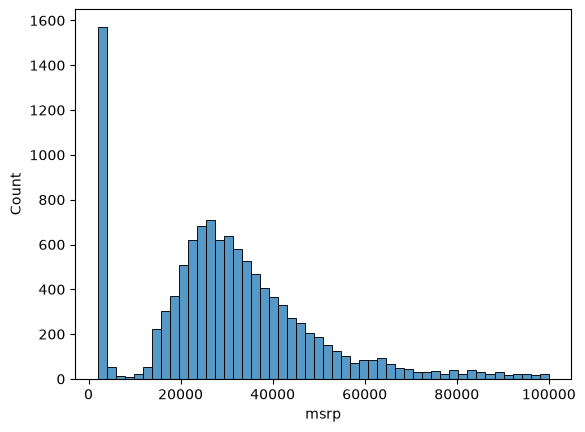

In [56]:
# sns.histplot(df.msrp, bins=50)
# sns.boxplot(df.msrp)
sns.histplot(df.msrp[df.msrp < 100000], bins=50)